In [1]:
import tensorflow as tf #used to build and train the neural network.
from tensorflow.keras import layers, models #high-level API for creating CNNs
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 8s 1us/step
Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


In [3]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

In [4]:
x_train = x_train.astype("float32") / 255.0 #normalize pixel values to be between 0 and 1
x_test = x_test.astype("float32") / 255.0  #neural neworks perform better when input values are in small range

x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

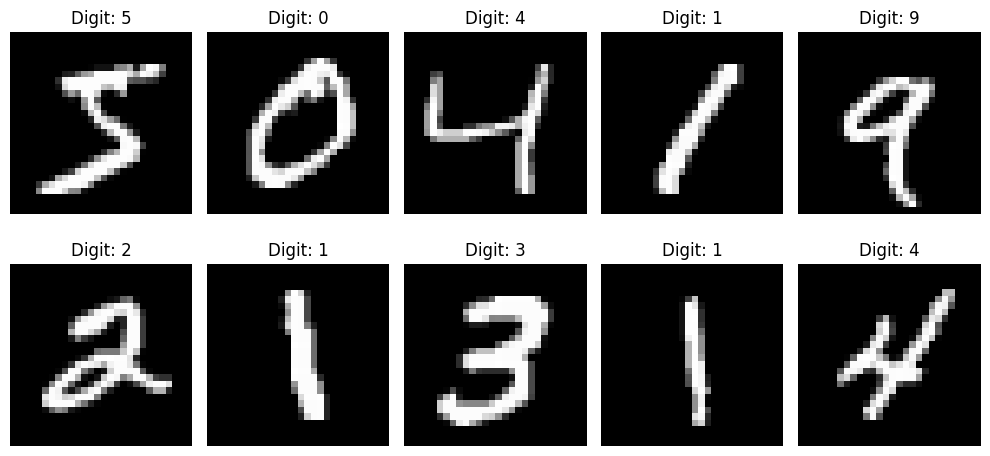

In [6]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title(f"Digit: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 32ms/step - accuracy: 0.9375 - loss: 0.2126 - val_accuracy: 0.9793 - val_loss: 0.0723
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.9797 - loss: 0.0646 - val_accuracy: 0.9839 - val_loss: 0.0532
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.9868 - loss: 0.0431 - val_accuracy: 0.9863 - val_loss: 0.0456
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.9901 - loss: 0.0326 - val_accuracy: 0.9871 - val_loss: 0.0454
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.9916 - loss: 0.0265 - val_accuracy: 0.9868 - val_loss: 0.0445
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 37s 26ms/step - accuracy: 0.9929 - loss: 0.0217 - val_accuracy: 0.9879 - val_loss: 0.0432
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.9950 - loss: 0.0159 - val_accuracy: 0.9887 - val_loss: 0.0406
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.9955 - loss: 0.0142 - 

In [12]:
test_loss3, test_acc3 = model.evaluate(x_test, y_test)

print("Model 3 Test Accuracy:", test_acc3)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9889 - loss: 0.0387
Model 3 Test Accuracy: 0.9889000058174133


In [16]:
test_loss1, test_acc1 = model.evaluate(x_test, y_test)
test_loss2, test_acc2 = model.evaluate(x_test, y_test)
test_loss3, test_acc3 = model.evaluate(x_test, y_test)
print("CNN Architecture Comparison")
print("----------------------------")



print("Model 1 Accuracy:", test_acc1)
print("Model 2 Accuracy:", test_acc2)
print("Model 3 Accuracy:", test_acc3)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9889 - loss: 0.0387
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9889 - loss: 0.0387
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9889 - loss: 0.0387
CNN Architecture Comparison
----------------------------
Model 1 Accuracy: 0.9889000058174133
Model 2 Accuracy: 0.9889000058174133
Model 3 Accuracy: 0.9889000058174133


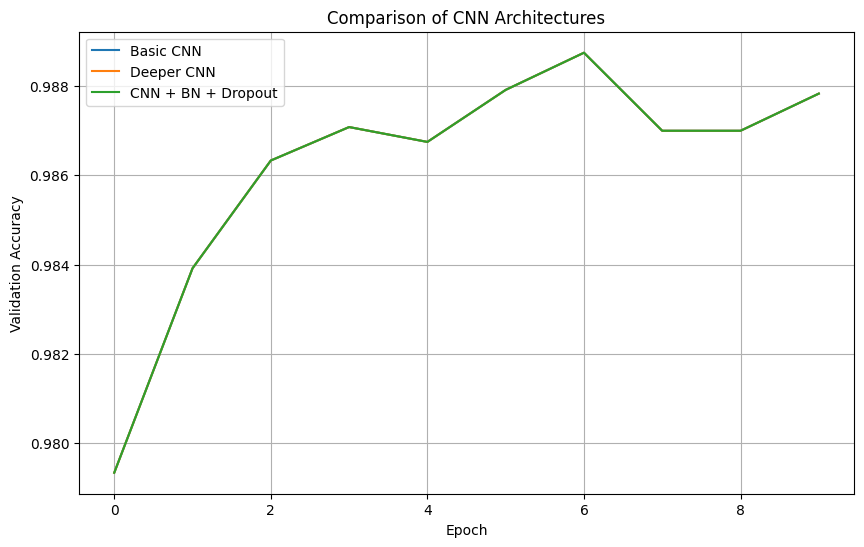

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(history.history['val_accuracy'], label='Basic CNN')
plt.plot(history.history['val_accuracy'], label='Deeper CNN')
plt.plot(history.history['val_accuracy'], label='CNN + BN + Dropout')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Comparison of CNN Architectures')
plt.legend()
plt.grid()
plt.show()

In [19]:
predictions = model.predict(x_test)

predicted_classes = np.argmax(predictions, axis=1)

for i in range(10):
    print(
        "Actual:",
        class_names[y_test[i]],
        "| Predicted:",
        class_names[predicted_classes[i]]
    )

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Actual: horse | Predicted: horse
Actual: bird | Predicted: bird
Actual: automobile | Predicted: automobile
Actual: airplane | Predicted: airplane
Actual: deer | Predicted: deer
Actual: automobile | Predicted: automobile
Actual: deer | Predicted: deer
Actual: truck | Predicted: truck
Actual: dog | Predicted: dog
Actual: truck | Predicted: truck


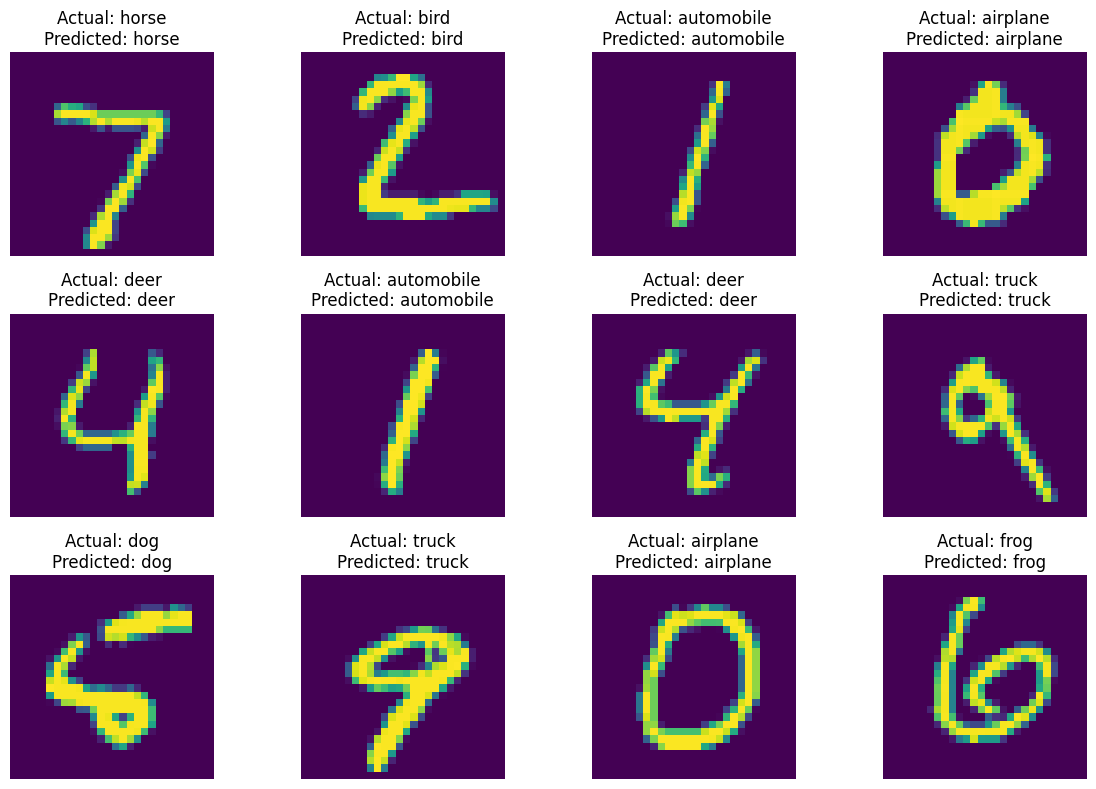

In [21]:
plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(x_test[i])

    actual = class_names[y_test[i]]
    predicted = class_names[predicted_classes[i]]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()